On utilise un notebook pour pouvoir afficher les sorties graphiques

In [1]:
from fonctions import load_gpkg, gdf_DBSCAN
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
import matplotlib.pyplot as plt

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_81_99.gpkg")



gdf["Annee"].unique()
gdf["aire"] = gdf.geometry.area

centroids = gdf.geometry.centroid
# Conversion en coordonnées géographiques (WGS84)
centroids_wgs84 = gpd.GeoSeries(centroids, crs=2154).to_crs(epsg=4326)
gdf["lon"] = centroids_wgs84.x
gdf["lat"] = centroids_wgs84.y

gdf=gdf[gdf["Annee"].isin([2008,2014,2020,2025])]



Téléchargement depuis mgarbe/BDTOPO/BDTOPO_BATI_merge_dep_81_99.gpkg ...
Chargement réussi (2958999 lignes)


Progress: 15/15 | eps : 281, clusters : 0.894, isolés : 0.106


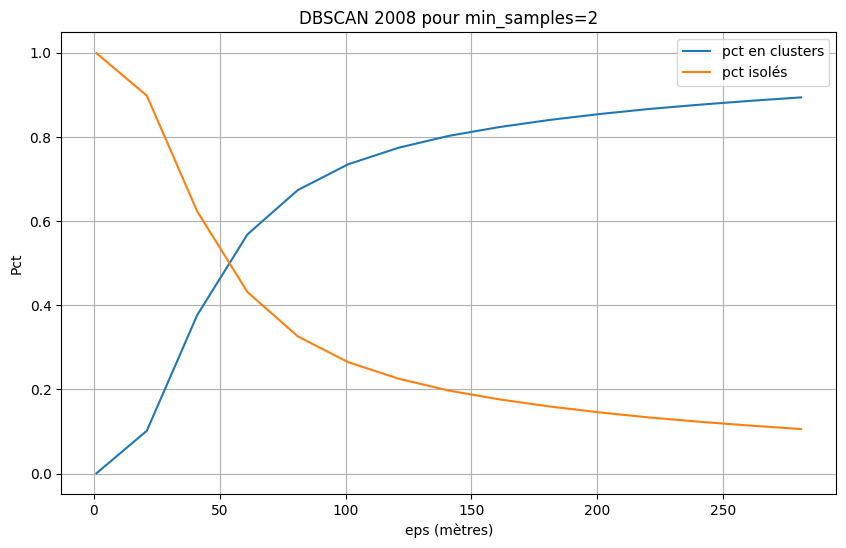

In [7]:
#clusters 
plot_DB_epsilon(gdf,2008,2,1,301,20)

In [ ]:
from fonctions import plot_DB_epsilon

#identification de sites industriels et logistiques
temp, n_clusters, n_isoles =gdf_DBSCAN(gdf,2008,eps=200,min_samples=2)
isolés = temp[temp["cluster_id"] == -1].copy()
clusterisés = temp[temp["cluster_id"] != -1].copy()
clusterisés["centroid"] = clusterisés.geometry.centroid
clusters_fusionnes = clusterisés.groupby("cluster_id")["centroid"].apply(
    lambda centroids: Point(
        np.mean([p.x for p in centroids]),
        np.mean([p.y for p in centroids])
    )
).reset_index()
gdf_clusters_fusionnes = gpd.GeoDataFrame(
    clusters_fusionnes, 
    geometry="centroid", 
    crs=temp.crs
)
gdf_clusters_fusionnes = gdf_clusters_fusionnes.set_geometry("centroid")
temp = pd.concat([isolés, gdf_clusters_fusionnes], ignore_index=True)
temp.drop(columns=["cluster_id"], inplace=True)



Clusters détectés : 32880
Bâtiments isolés : 65312


Progress: 150/150 | eps : 2981, clusters : 0.997, isolés : 0.003


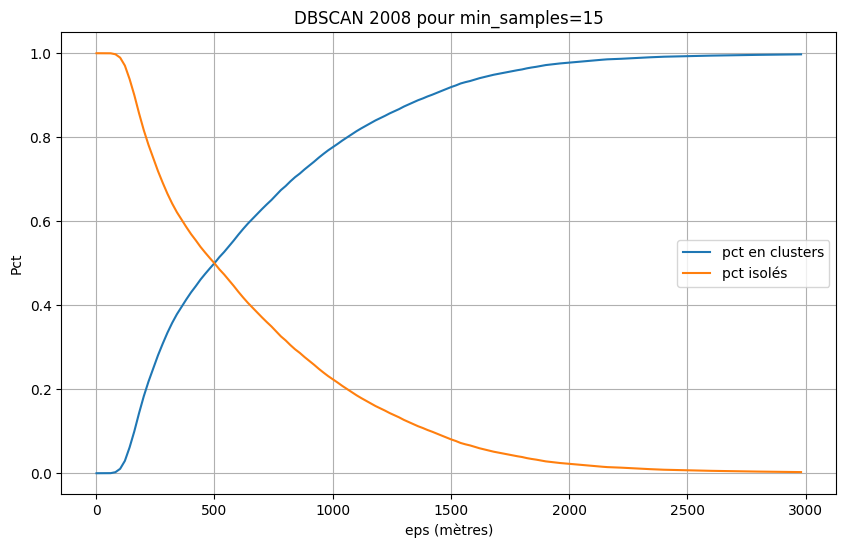

In [13]:
plot_DB_epsilon(gdf,2008,15,1,3001,20)

Progress: 40/40 | eps : 1951, clusters : 0.916, isolés : 0.084


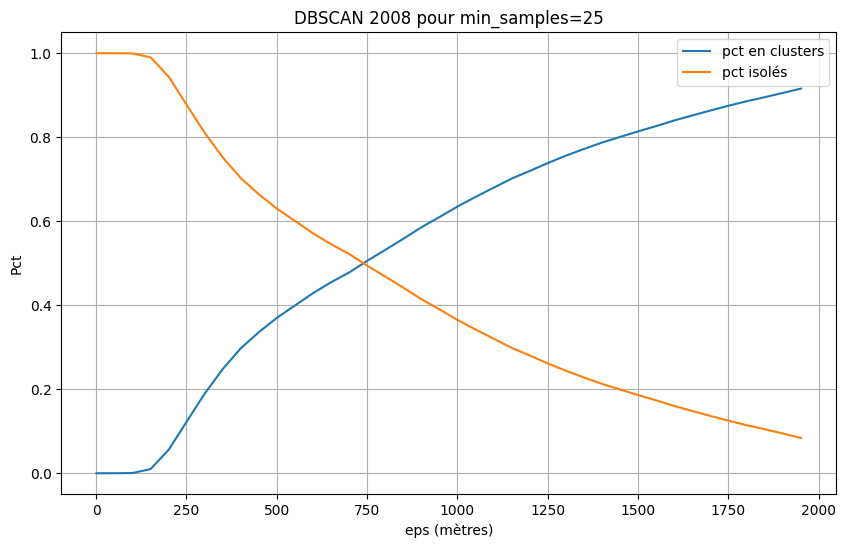

In [18]:
plot_DB_epsilon(gdf,2008,25,1,2001,50)

Progress: 100/100 | eps : 1981, clusters : 0.987, isolés : 0.013


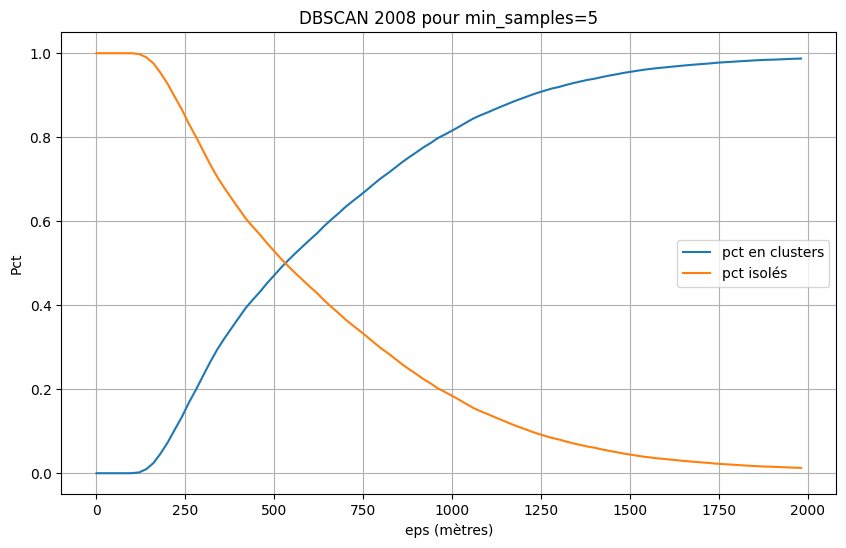

In [17]:
plot_DB_epsilon(temp,2008,5,1,2001)

Progress: 100/100 | eps : 1981, clusters : 0.936, isolés : 0.064


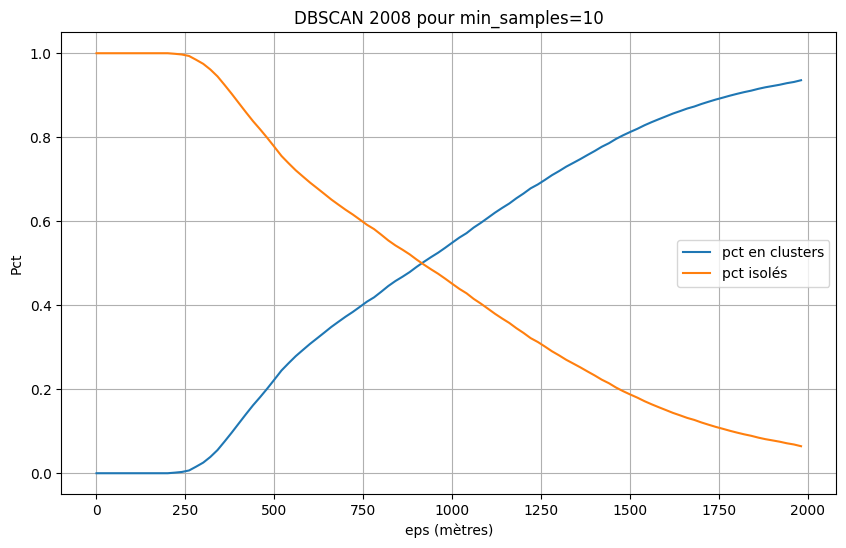

In [16]:
plot_DB_epsilon(temp,2008,10,1,2001)